# Faz 3 — Time-based Split ve Baseline LightGBM

Faz 2'de kaydedilen `features.parquet` uzerinden devam ediyoruz.

## 1. Veri Yukleme ve Feature/Split Tanimi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import pickle

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
FIG_DIR = '../reports/figures'

df = pd.read_parquet('../data/features.parquet')
print(df.shape)
print('week range:', df['week'].min(), '-', df['week'].max())

(456548, 26)
week range: 1 - 145


### Time-based split — son 10 hafta test

Panel veri (center x meal x hafta) oldugu icin rastgele split yerine zaman bazli split kullaniyoruz: son 10 hafta (136-145) test, geri kalan 135 hafta train. Bu sekilde gelecegi gecmisten tahmin eden gercekci bir degerlendirme yapiyoruz.

In [2]:
SPLIT_WEEK = df['week'].max() - 10  # 135

feature_cols = [
    'checkout_price', 'base_price', 'discount_ratio',
    'emailer_for_promotion', 'homepage_featured',
    'num_orders_lag_1', 'num_orders_lag_4', 'num_orders_roll_mean_4',
    'weekofyear', 'week_sin', 'week_cos',
    'center_type_enc', 'category_enc', 'cuisine_enc',
    'city_code', 'region_code', 'op_area',
    'center_id', 'meal_id',
]
cat_features = ['center_type_enc', 'category_enc', 'cuisine_enc', 'center_id', 'meal_id']
target_col = 'log_num_orders'

train_df = df[df['week'] <= SPLIT_WEEK].copy()
test_df = df[df['week'] > SPLIT_WEEK].copy()
print('train:', train_df.shape, 'test:', test_df.shape)
print('train hafta araligi:', train_df['week'].min(), '-', train_df['week'].max())
print('test hafta araligi :', test_df['week'].min(), '-', test_df['week'].max())

train: (423727, 26) test: (32821, 26)
train hafta araligi: 1 - 135
test hafta araligi : 136 - 145


## 2. Baseline LightGBM (RMSLE optimizasyonu)

Hedef zaten `log1p(num_orders)` oldugu icin, standart RMSE objective'i ile egitilen model aslinda orijinal olcekte RMSLE'yi optimize etmis oluyor.

In [3]:
lgb_train = lgb.Dataset(train_df[feature_cols], label=train_df[target_col], categorical_feature=cat_features)
lgb_valid = lgb.Dataset(test_df[feature_cols], label=test_df[target_col], categorical_feature=cat_features, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_data_in_leaf': 30,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 1,
    'verbose': -1,
    'seed': 42,
}

baseline_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=['train', 'valid'],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)],
)

Training until validation scores don't improve for 100 rounds


[200]	train's rmse: 0.465872	valid's rmse: 0.480215


[400]	train's rmse: 0.447024	valid's rmse: 0.47683


[600]	train's rmse: 0.436038	valid's rmse: 0.476336


Early stopping, best iteration is:
[594]	train's rmse: 0.436274	valid's rmse: 0.476281


## 3. Model Evaluation — RMSLE ve MAE (orijinal olcek)

In [4]:
pred_log = baseline_model.predict(test_df[feature_cols], num_iteration=baseline_model.best_iteration)
pred_orders = np.clip(np.expm1(pred_log), 0, None)
actual_orders = test_df['num_orders'].values

rmsle = np.sqrt(np.mean((np.log1p(pred_orders) - np.log1p(actual_orders)) ** 2))
mae = mean_absolute_error(actual_orders, pred_orders)

print(f'RMSLE: {rmsle:.4f}')
print(f'MAE  : {mae:.2f}')

test_df = test_df.assign(pred_num_orders=pred_orders)

RMSLE: 0.4763
MAE  : 62.12


### Residual plot

Regresyon problemi oldugu icin confusion matrix / ROC egrisi anlamli degil; bunlarin yerine tahmin hatalarinin dagilimini gosteren residual plot kullaniyoruz.

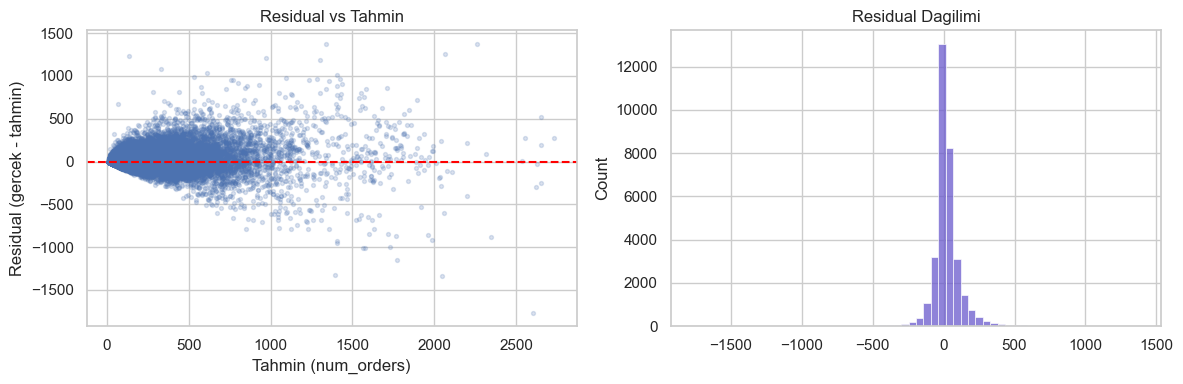

In [5]:
residuals = actual_orders - pred_orders

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred_orders, residuals, alpha=0.2, s=8)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Tahmin (num_orders)'); axes[0].set_ylabel('Residual (gercek - tahmin)')
axes[0].set_title('Residual vs Tahmin')

sns.histplot(residuals, bins=60, ax=axes[1], color='slateblue')
axes[1].set_title('Residual Dagilimi')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/faz3_residual_plot.png', dpi=120)
plt.show()

## 4. Feature Importance

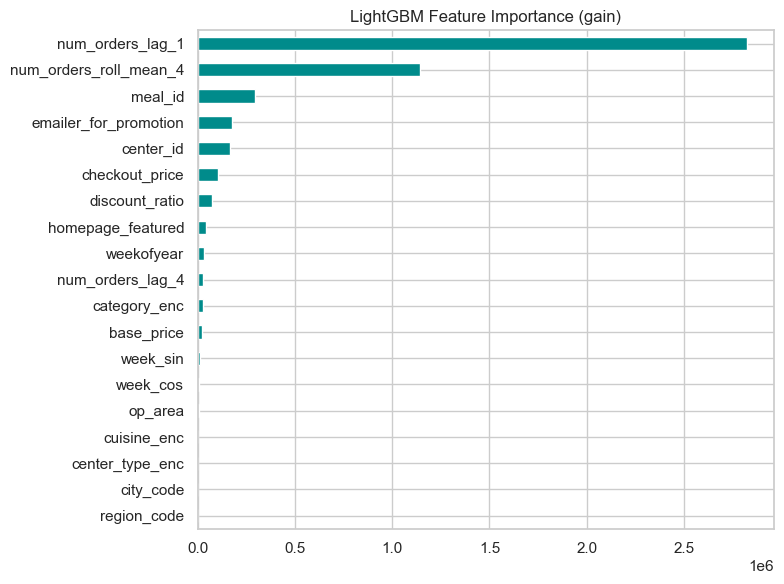

num_orders_lag_1          2.821243e+06
num_orders_roll_mean_4    1.141232e+06
meal_id                   2.945569e+05
emailer_for_promotion     1.754154e+05
center_id                 1.687683e+05
checkout_price            1.036258e+05
discount_ratio            7.645140e+04
homepage_featured         4.308176e+04
weekofyear                3.520451e+04
num_orders_lag_4          2.940655e+04
category_enc              2.805401e+04
base_price                2.243519e+04
week_sin                  1.028275e+04
week_cos                  7.924057e+03
op_area                   4.808082e+03
cuisine_enc               3.546496e+03
center_type_enc           7.654495e+02
city_code                 3.079191e+02
region_code               2.507235e+02
dtype: float64

In [6]:
importance = pd.Series(
    baseline_model.feature_importance(importance_type='gain'),
    index=feature_cols
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot(kind='barh', ax=ax, color='darkcyan')
ax.invert_yaxis()
ax.set_title('LightGBM Feature Importance (gain)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/faz3_feature_importance.png', dpi=120)
plt.show()
importance

## Ozet

- Time-based split: train = 1-135. hafta, test = son 10 hafta (136-145).
- Baseline LightGBM, `log1p(num_orders)` hedefiyle egitildi -> RMSE objective, orijinal olcekte RMSLE'ye denk geliyor.
- Test setinde **RMSLE** ve **MAE** raporlandi (yukaridaki cikti).
- Residual plot: hatalarin cogunlukla 0 etrafinda toplandigini, buyuk taleplerde varyansin arttigini gosteriyor (regresyon oldugu icin confusion matrix/ROC yerine bu grafik kullanildi).
- Feature importance: gecmis talep tabanli feature'lar (`num_orders_roll_mean_4`, `num_orders_lag_1`) en onemli degiskenler.

Model ve split, Faz 4'te (quantile modeller) tekrar kullanilmak uzere kaydediliyor.

In [7]:
baseline_model.save_model('../data/baseline_lgb_model.txt')
with open('../data/split_config.pkl', 'wb') as f:
    pickle.dump({'feature_cols': feature_cols, 'cat_features': cat_features,
                 'target_col': target_col, 'split_week': SPLIT_WEEK}, f)
test_df.to_parquet('../data/test_with_baseline_pred.parquet', index=False)
print('Kaydedildi.')

Kaydedildi.
